# PCA vs Laplacian Eigenmaps — Yale Faces

This notebook compares PCA and Laplacian Eigenmaps on the **same Yale Face dataset** and uses the **estimated intrinsic dimension** as the common target dimension.

Pipeline:

**32,256D Yale faces → TWO-NN → intrinsic dimension ≈ 7 → PCA 7D vs Laplacian Eigenmaps 7D**

Both methods are evaluated using **10-NN neighborhood preservation** in the original high-dimensional space.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from intrinsic_dimension import estimate_intrinsic_dimension
from laplacian_eigenmaps import laplacian_eigenmaps

np.random.seed(42)

## 1. Load and preprocess Yale Face data

In [2]:
def load_yale_subject(folder_path, max_images=400):
    images = []

    for file in os.listdir(folder_path):
        if file.endswith(".pgm") and "Ambient" not in file:
            img_path = os.path.join(folder_path, file)

            img = Image.open(img_path)
            img = np.array(img, dtype=np.float32)

            images.append(img.flatten())

            if len(images) >= max_images:
                break

    return np.array(images)


subject_path = "cropped/yaleB39"

X = load_yale_subject(subject_path, max_images=400)

print("Dataset shape:", X.shape)

# Same preprocessing as the main Yale experiment
X = X - X.mean(axis=1, keepdims=True)
X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

print("Preprocessing complete.")

Dataset shape: (400, 32256)
Preprocessing complete.


## 2. Estimate intrinsic dimension

In [3]:
d_est = estimate_intrinsic_dimension(X)

target_dim = int(round(d_est))

print(f"Estimated intrinsic dimension: {d_est:.3f}")
print(f"Target dimension for comparison: {target_dim}")

Estimated intrinsic dimension: 7.015
Target dimension for comparison: 7


## 3. PCA — 32,256D → 7D

PCA is given the **same target dimension** estimated by TWO-NN for Laplacian Eigenmaps.

In [4]:
pca = PCA(n_components=target_dim)
Y_pca = pca.fit_transform(X)

pca_variance = pca.explained_variance_ratio_.sum() * 100

print("PCA embedding shape:", Y_pca.shape)
print(f"PCA variance explained by {target_dim} components: {pca_variance:.2f}%")

PCA embedding shape: (400, 7)
PCA variance explained by 7 components: 66.88%


## 4. Laplacian Eigenmaps — 32,256D → 7D

The same target dimension is used for Laplacian Eigenmaps.

In [5]:
Y_le = laplacian_eigenmaps(
    X,
    n_neighbors=20,
    n_components=target_dim
)

print("Laplacian Eigenmaps embedding shape:", Y_le.shape)

Connected components: 1
Smallest eigenvalues: [-2.41192144e-16  4.92001784e-02  1.06004338e-01  1.30219836e-01
  1.36440637e-01]
Laplacian Eigenmaps embedding shape: (400, 7)


## 5. 10-NN neighborhood preservation

In [13]:
def knn_neighborhood_preservation(X_original, X_embedding, k=10):
    """Average percentage of original k-NN neighbors retained."""

    nn_original = NearestNeighbors(n_neighbors=k + 1)
    nn_original.fit(X_original)
    _, idx_original = nn_original.kneighbors(X_original)

    nn_embedding = NearestNeighbors(n_neighbors=k + 1)
    nn_embedding.fit(X_embedding)
    _, idx_embedding = nn_embedding.kneighbors(X_embedding)

    scores = []

    for i in range(len(X_original)):
        original_neighbors = set(idx_original[i, 1:])
        embedded_neighbors = set(idx_embedding[i, 1:])

        preserved = len(
            original_neighbors.intersection(embedded_neighbors)
        )

        scores.append(preserved / k)

    return np.mean(scores) * 100


k = 9

pca_knn = knn_neighborhood_preservation(X, Y_pca, k=k)
le_knn = knn_neighborhood_preservation(X, Y_le, k=k)

print(f"PCA {k}-NN preservation: {pca_knn:.2f}%")
print(f"Laplacian Eigenmaps {k}-NN preservation: {le_knn:.2f}%")

PCA 9-NN preservation: 68.69%
Laplacian Eigenmaps 9-NN preservation: 55.44%


## 6. Visual comparison

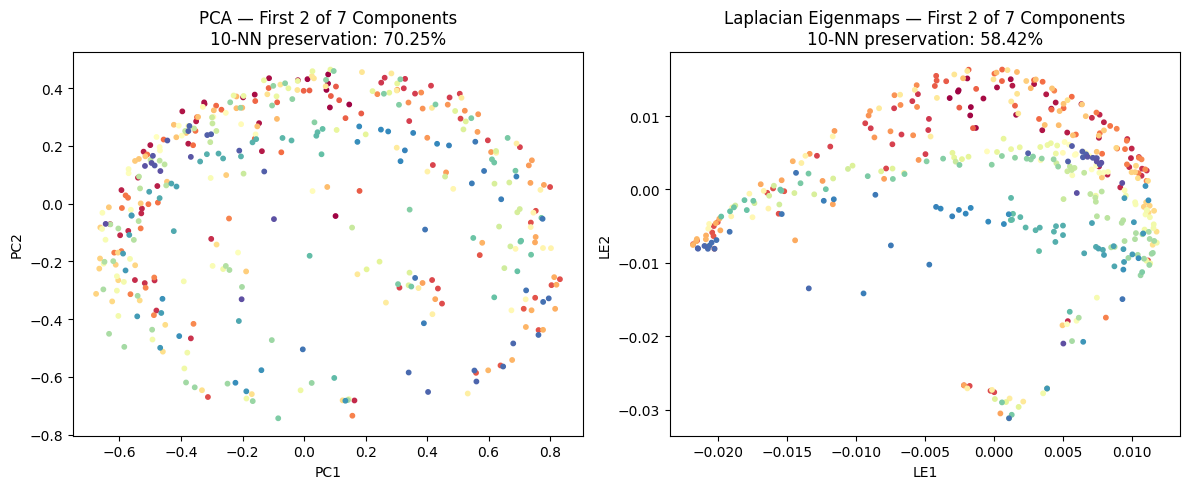

In [7]:
# Visualize the first two coordinates of the 7D embeddings.
# The quantitative comparison uses all 7 dimensions.

colors = np.arange(len(X))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    Y_pca[:, 0],
    Y_pca[:, 1],
    c=colors,
    cmap="Spectral",
    s=10
)
axes[0].set_title(
    f"PCA — First 2 of {target_dim} Components\n"
    f"{k}-NN preservation: {pca_knn:.2f}%"
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    Y_le[:, 0],
    Y_le[:, 1],
    c=colors,
    cmap="Spectral",
    s=10
)
axes[1].set_title(
    f"Laplacian Eigenmaps — First 2 of {target_dim} Components\n"
    f"{k}-NN preservation: {le_knn:.2f}%"
)
axes[1].set_xlabel("LE1")
axes[1].set_ylabel("LE2")

plt.tight_layout()
plt.show()

## 7. Final comparison

In [8]:
results = pd.DataFrame({
    "Method": ["PCA", "Laplacian Eigenmaps"],
    "Input Dimension": [X.shape[1], X.shape[1]],
    "Output Dimension": [target_dim, target_dim],
    "10-NN Preservation (%)": [pca_knn, le_knn]
})

results

,Method,Input Dimension,Output Dimension,10-NN Preservation (%)
0,PCA,32256,7,70.250
1,Laplacian Eigenmaps,32256,7,58.425


### Interpretation

Both methods reduce the same **32,256-dimensional Yale data to the same ~7-dimensional target space**.

The primary common metric is **10-NN neighborhood preservation**, since preserving local structure is the objective of Laplacian Eigenmaps.

PCA's explained variance is also reported, but it is treated as a **PCA-specific metric** rather than being directly compared with Laplacian Eigenmaps.